In [1]:
!pip install neuralforecast utilsforecast holidays

import logging
import holidays
import pandas as pd

from utilsforecast.evaluation import evaluate
from utilsforecast.plotting import plot_series
from utilsforecast.losses import bias, rmse, mae, mape

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS
from neuralforecast.utils import AirPassengersDF

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.2/532.2 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)

In [7]:
us_holidays = holidays.US(years=range(2020, 2024))

df = (
    pd.read_parquet("/work/sample_hotels.parquet")
    .query("unique_id not in ['hotel_77', 'hotel_28']")
    .drop(columns=['target_month', 'target_year', 'location_type'])
    .assign(
        ds = lambda x: pd.to_datetime(x["ds"]),
        unique_id = lambda x: x["unique_id"].astype(str),
        y = lambda x: x["y"].astype(float),

        hotel_type = lambda x: x['hotel_type'].astype('category'),
        # create holiday_name from holiday_flag
        holiday_name = lambda x: (
            x['ds'].dt.date.apply(lambda y: us_holidays.get(y))
            .astype('category')
            .cat.add_categories('None')
            .fillna('None')
        ),
        # create day_of_week from the actual timestamp
        day_of_week = lambda x: x.ds.dt.day_name().astype('category')
    )
    # drop holiday_flag and target_day now that we have holiday_name and day_of_week
    .drop(columns=['holiday_flag', 'target_day']) 
)

# transform categories into binary variables
df = pd.get_dummies(df, columns=['day_of_week', 'holiday_name', 'hotel_type'], drop_first=True)

cols_to_keep = [
    col for col in df.columns 
    if not col.startswith('otb_') or col in ['otb_28', 'otb_30', 'otb_46']
]

df = df[cols_to_keep]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9282 entries, 1430 to 298041
Data columns (total 29 columns):
 #   Column                                                        Non-Null Count  Dtype         
---  ------                                                        --------------  -----         
 0   unique_id                                                     9282 non-null   object        
 1   ds                                                            9282 non-null   datetime64[us]
 2   y                                                             9282 non-null   float64       
 3   otb_28                                                        9282 non-null   float64       
 4   otb_30                                                        9282 non-null   float64       
 5   otb_46                                                        9282 non-null   float64       
 6   day_of_week_Monday                                            9282 non-null   bool          
 7   day_of

Seed set to 1
Seed set to 1
/root/venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


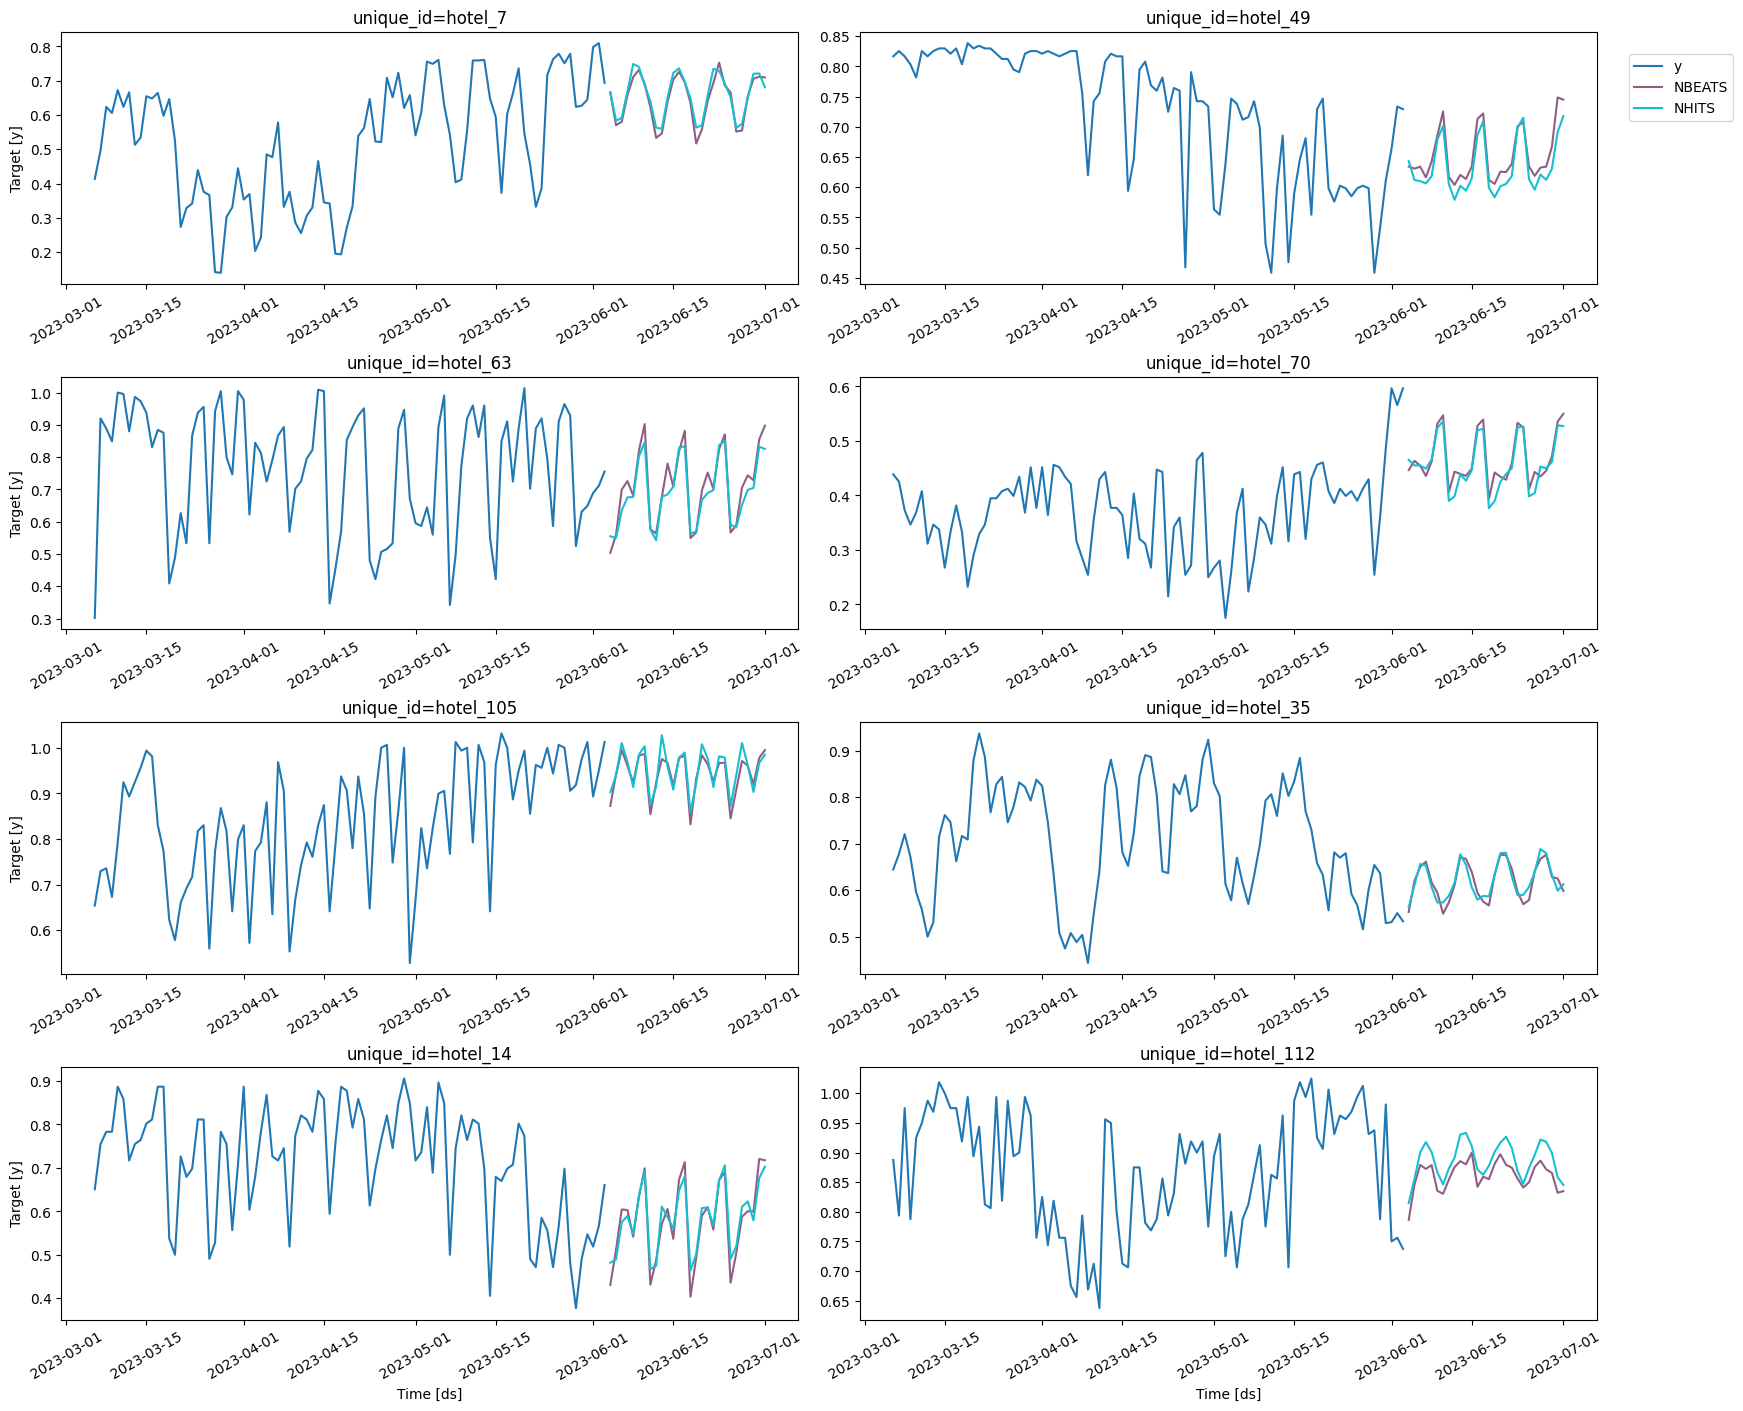

In [11]:
# Split data and declare panel dataset
train = df.query("ds <= '2023-06-03'")
test = df.query("ds > '2023-06-03'")

# fit and predict with NBEATS and NHITS models
horizon = 28
models = [NBEATS(input_size=2 * horizon, h=horizon, max_steps=100, enable_progress_bar=False),
          NHITS(input_size=2 * horizon, h=horizon, max_steps=100, enable_progress_bar=False)]
nf = NeuralForecast(models=models, freq='D')

nf.fit(df=train)

Y_hat_df = nf.predict()

# Get the list of all 17 unique IDs
all_hotels = df['unique_id'].unique().tolist()

# Use 'ids' instead of 'unique_ids'
plot_series(train, Y_hat_df, ids=all_hotels, max_insample_length=90)

In [13]:
# Check how many hotels we started with vs how many we forecasted
original_count = train['unique_id'].nunique()
forecasted_count = Y_hat_df['unique_id'].nunique()

print(f"Hotels in Training Set: {original_count}")
print(f"Hotels in Forecast Set: {forecasted_count}")

if forecasted_count < original_count:
    missing = set(train['unique_id'].unique()) - set(Y_hat_df['unique_id'].unique())
    print(f"The following hotels were dropped because they have < 56 days of data: {missing}")

Hotels in Training Set: 17
Hotels in Forecast Set: 17


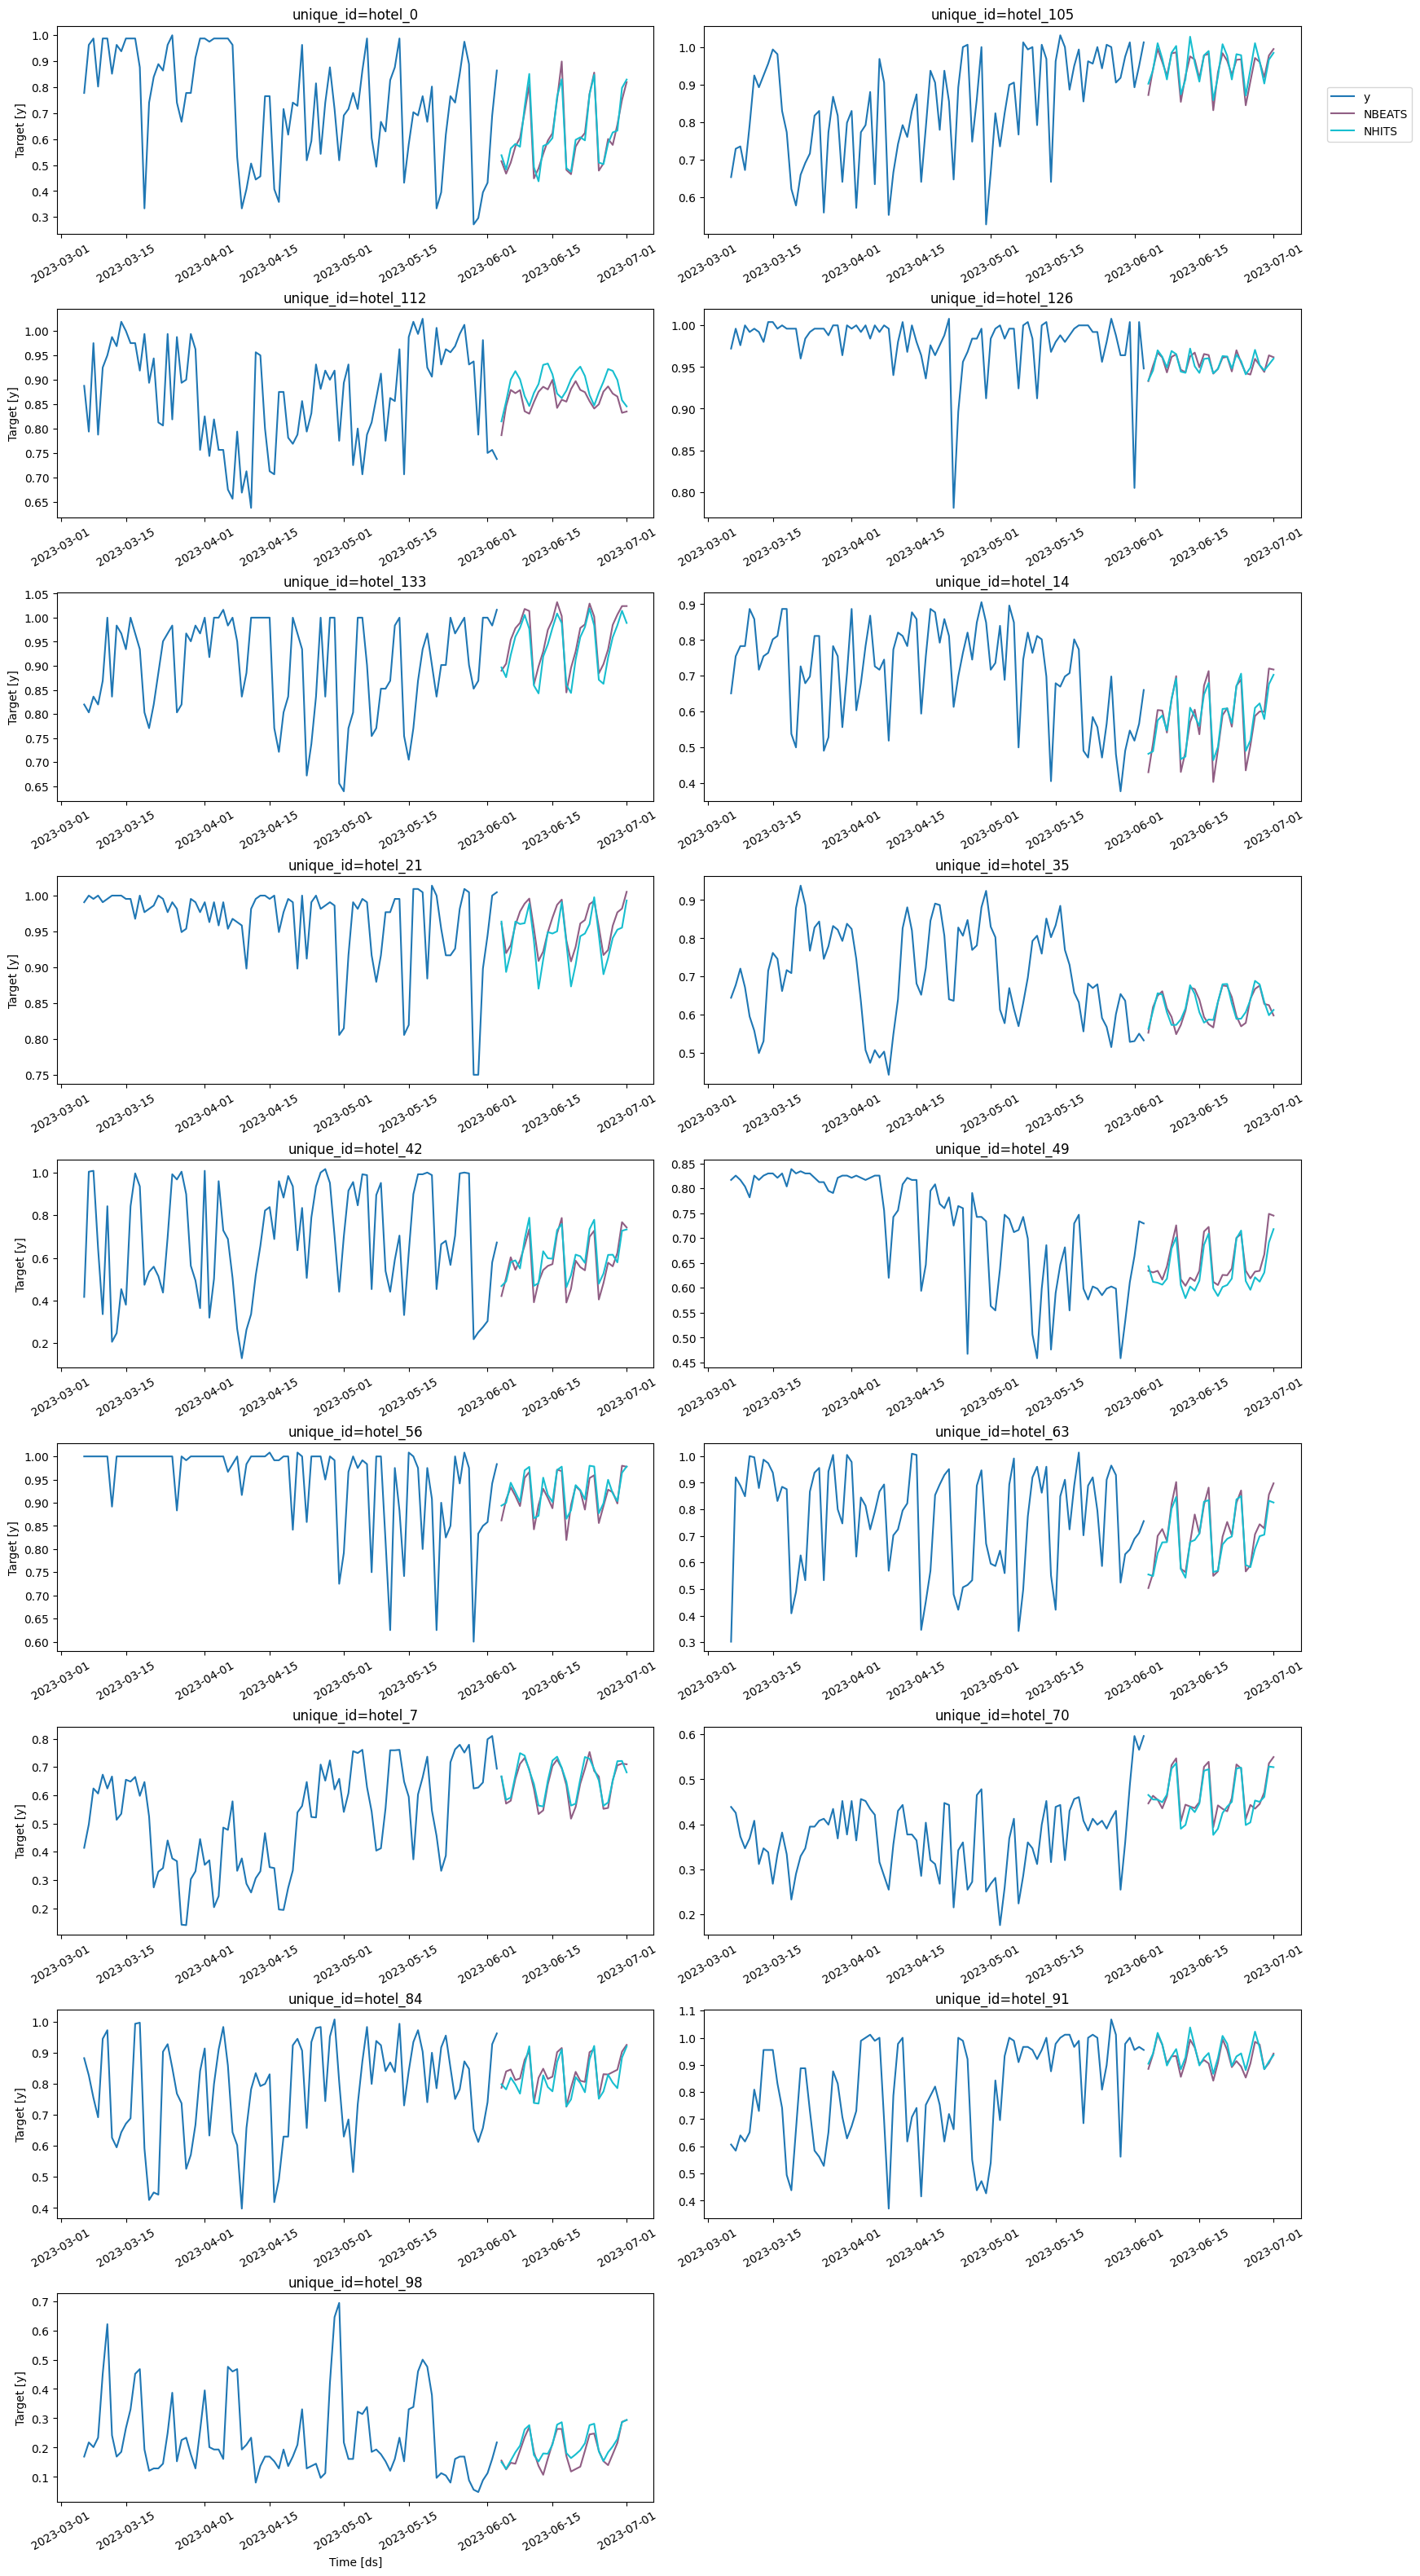

In [15]:
from utilsforecast.plotting import plot_series

# Get the list of all 17 hotel IDs
all_hotels = Y_hat_df['unique_id'].unique().tolist()

# 1. Use max_ids=17 to override the default limit of 8
# 2. Removed 'columns' to fix the TypeError
plot_series(
    train, 
    Y_hat_df, 
    ids=all_hotels, 
    max_ids=17, 
    max_insample_length=90
)

In [17]:
eval_neural_df = Y_hat_df.merge(test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])

# evaluate 
eval_neural = evaluate(
    df = eval_neural_df,
    metrics = [bias, mae, rmse, mape],
    models = ['NBEATS', 'NHITS'],
    target_col = 'y' 
)


eval_summary = eval_neural.groupby(['unique_id','metric']).mean().reset_index(inplace=False)
print(eval_summary)

    unique_id metric    NBEATS     NHITS
0     hotel_0   bias -0.118201 -0.112344
1     hotel_0    mae  0.118865  0.114983
2     hotel_0   mape  0.160254  0.153631
3     hotel_0   rmse  0.141672  0.141362
4   hotel_105   bias -0.055530 -0.046222
..        ...    ...       ...       ...
63   hotel_91   rmse  0.067576  0.077057
64   hotel_98   bias  0.004584  0.025096
65   hotel_98    mae  0.087130  0.097410
66   hotel_98   mape  0.747689  0.895130
67   hotel_98   rmse  0.108360  0.111826

[68 rows x 4 columns]


### Aggregate evaluation metrics and count model wins

In [19]:
# 1. Aggregate evaluation metrics (Overall Mean)
# This gives you a high-level view of which model is better on average
overall_performance = eval_neural.drop(columns='unique_id').groupby('metric').mean()
print("\n--- Aggregate Evaluation Metrics (Average) ---")
print(overall_performance)

# 2. Count Model Wins
# We use MAE (Mean Absolute Error) as the tie-breaker to see which model was more accurate per hotel
# .idxmin(axis=1) finds the column name (NBEATS or NHITS) with the lowest value
wins_table = eval_neural.query("metric == 'mae'").copy()
wins_table['winner'] = wins_table[['NBEATS', 'NHITS']].idxmin(axis=1)

model_wins = wins_table['winner'].value_counts()
print("\n--- Model Win Counts (Based on MAE) ---")
print(model_wins)


--- Aggregate Evaluation Metrics (Average) ---
          NBEATS     NHITS
metric                    
bias   -0.041826 -0.040058
mae     0.091122  0.093600
mape    0.164737  0.176769
rmse    0.109977  0.112427

--- Model Win Counts (Based on MAE) ---
winner
NBEATS    11
NHITS      6
Name: count, dtype: int64


### Generate final test forecasts and export results to CSV

In [21]:
# 1. Ensure the forecasts are clearly labeled
# Y_hat_df contains the predictions for NBEATS and NHITS for the next 28 days
final_forecasts = Y_hat_df.copy()

# 2. Export to CSV
# We use index=False to avoid adding an unnecessary row-number column
final_forecasts.to_csv('neural_forecast_results.csv', index=False)

print("Final forecasts exported to neural_forecast_results.csv")

Final forecasts exported to neural_forecast_results.csv


### Create forecast\-vs\-actual plots for every series

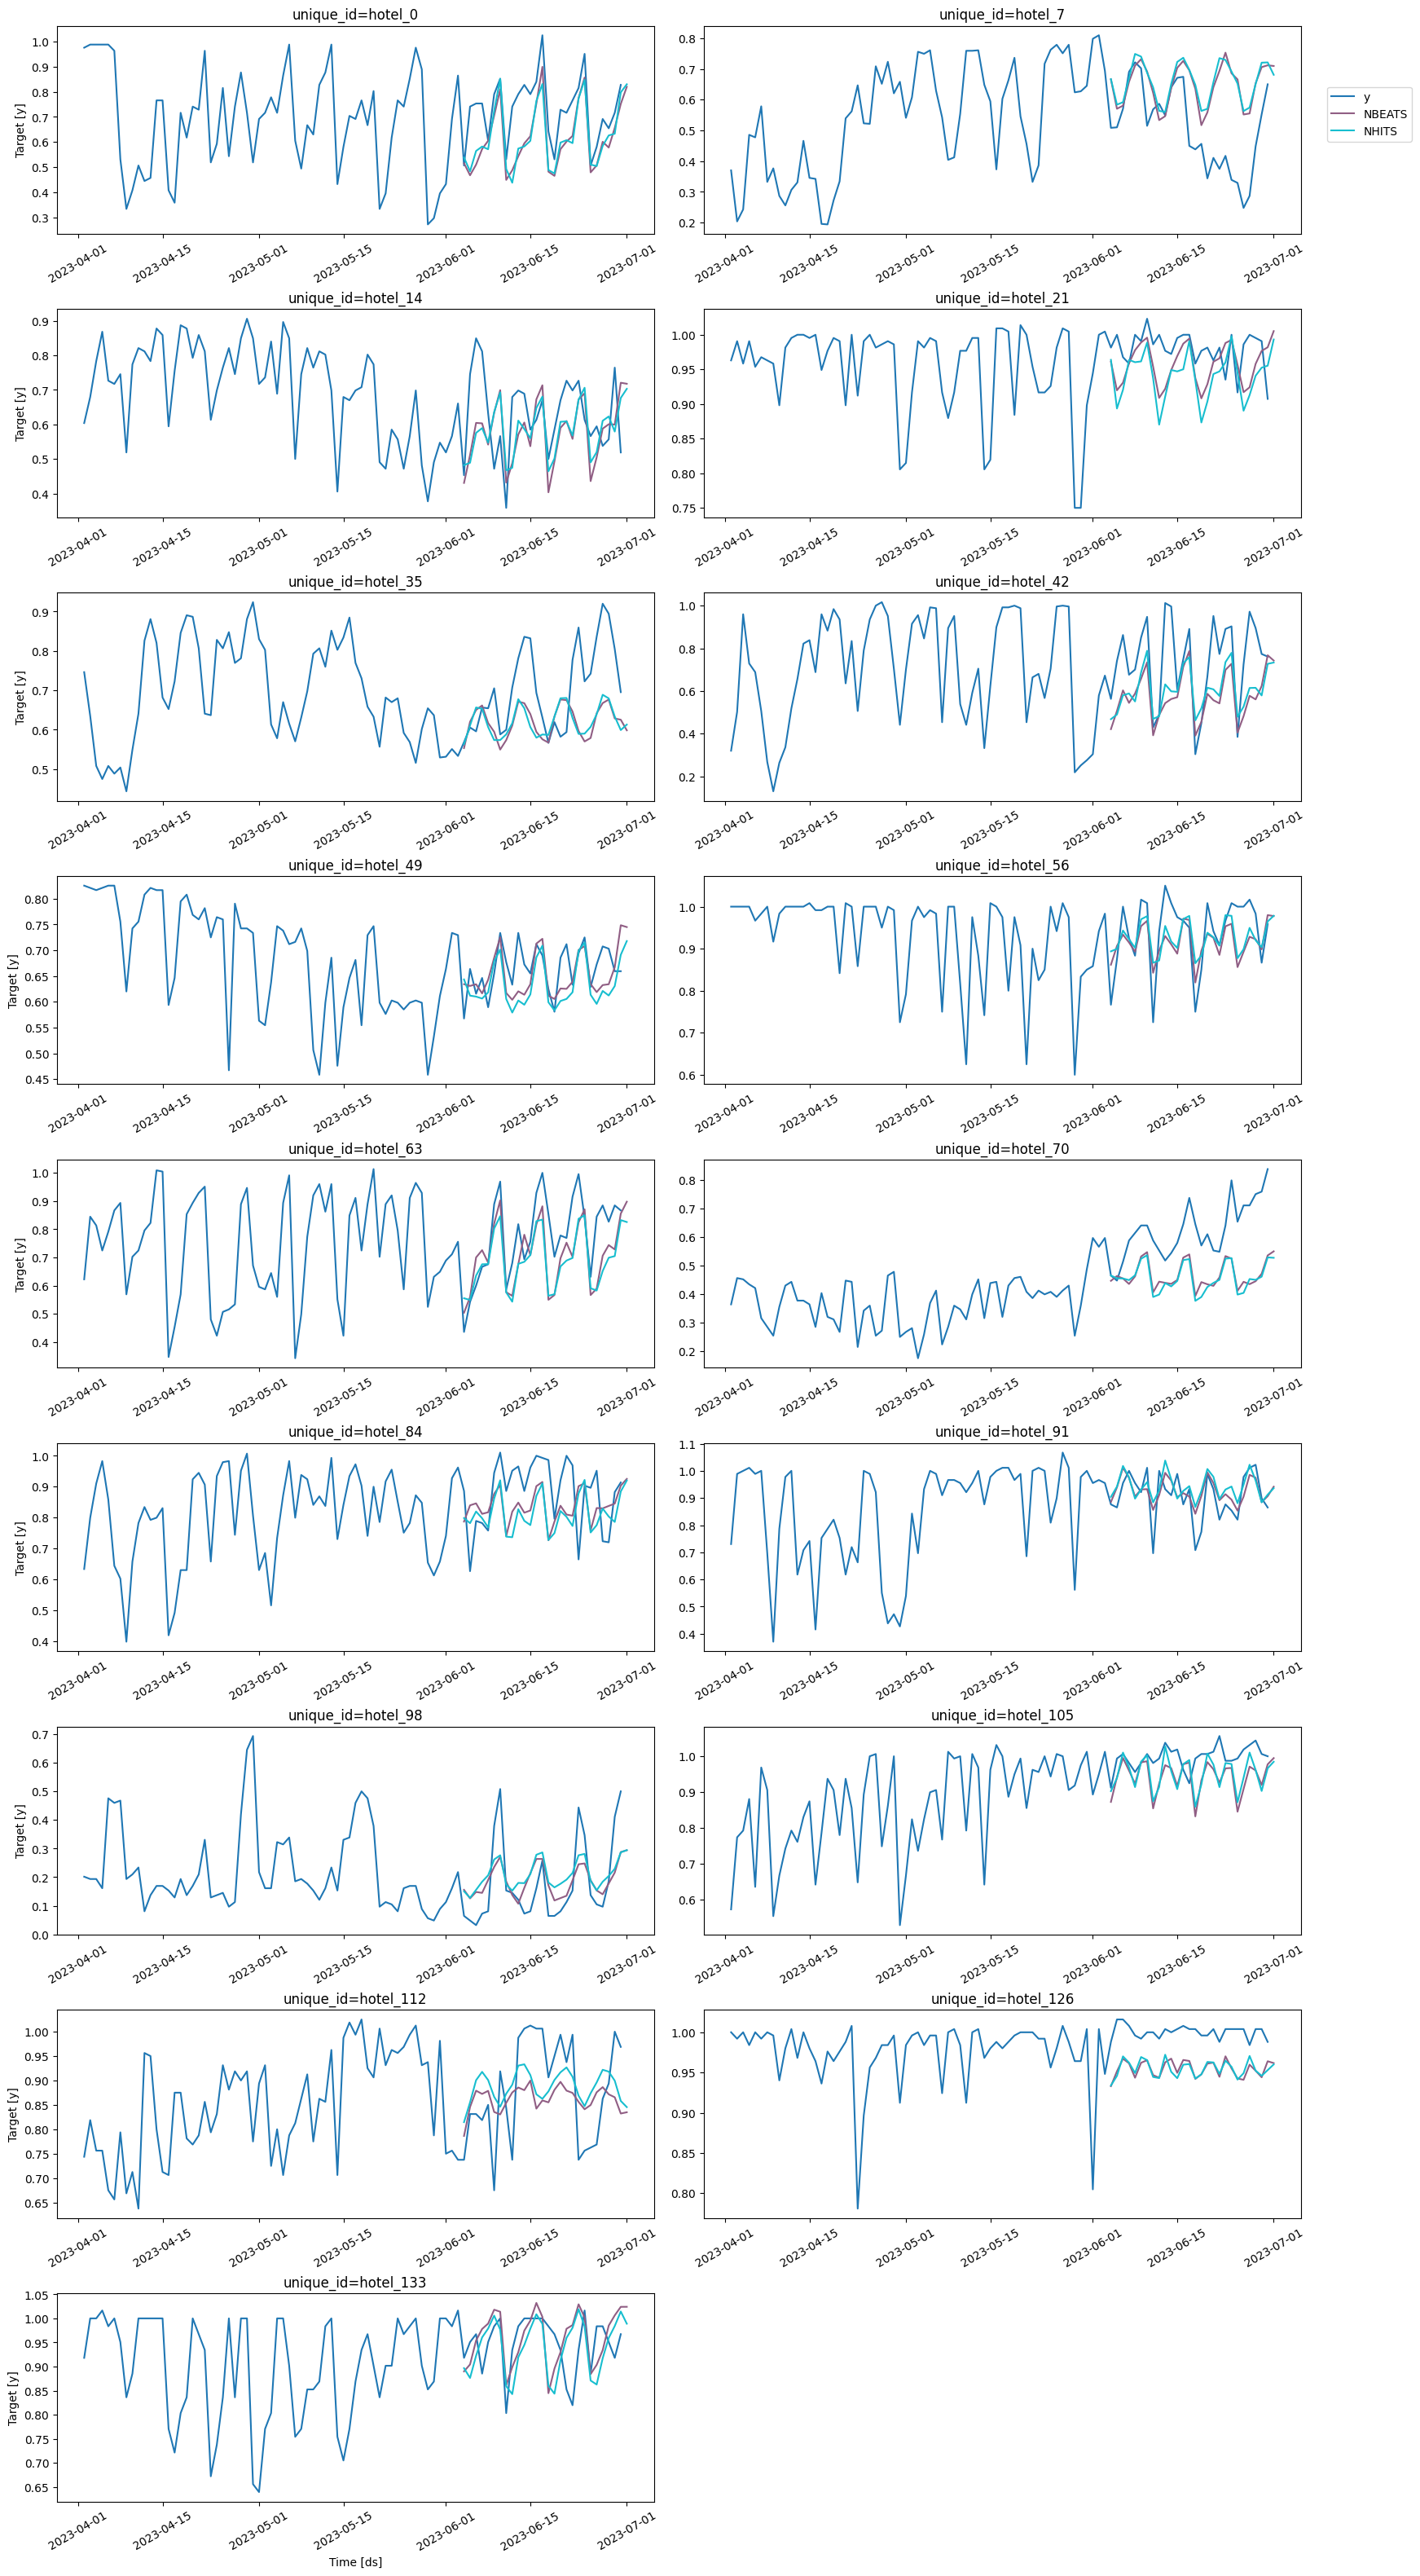

In [23]:
# 1. Merge actuals and forecasts for plotting
# We use the full 'df' to show historical data, and Y_hat_df for the predictions
all_hotels = df['unique_id'].unique().tolist()

# 2. Generate the plots
# - df: The original data (contains the 'y' values for both train and test periods)
# - Y_hat_df: The predictions from your neural models
# - max_insample_length=90: Shows 90 days of history before the forecast starts
# - max_ids=17: Forces the plot to show all hotels instead of the default 8
plot_series(
    df, 
    Y_hat_df, 
    ids=all_hotels, 
    max_ids=17, 
    max_insample_length=90,
    target_col='y'
)

### Additional Summary

In [47]:
# collapses the 17 hotels into one "Average Hotel" profile
eval_final_summary = (
    eval_summary
    .drop(columns='unique_id')
    .groupby('metric')
    .mean()
    .reset_index()
)

print(eval_final_summary)

  metric    NBEATS     NHITS
0   bias -0.041826 -0.040058
1    mae  0.091122  0.093600
2   mape  0.164737  0.176769
3   rmse  0.109977  0.112427


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f83e4db7-0c23-436a-9211-ebdab13126d5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>